# Water Burden Explorer — water-first crop ranking (Heidi's investigation)
**Feeds the Reverse_Water_Stress_Crop_Driver notebook. Question: in high-stress countries with real agriculture, which crops cost the most water, where, and what's pressuring them?**

Fixes two gaps in the current approach:
1. **Materiality filter**: stress-only ranking surfaces desert states with no farming (the Libya problem); crop-only ranking surfaces water-rich giants (the Russia/barley problem). We take the intersection.
2. **Water intensity**: harvested area is not water cost. A hectare of rain-fed wheat and a hectare of irrigated rice are different water stories. We weight by blue-water footprint (m3/ton) from Mekonnen & Hoekstra (2011), the standard reference (already cited in our notes doc).

Core metric: **water burden = production (tons) x blue footprint (m3/ton)**, computed per country-crop, filtered to stressed-and-material countries. Runs top to bottom in Colab; reuses dataframes from Kaveesha's notebook if already in memory.

In [ ]:
# Bootstrap: fetch the team data loader from the fork (opening a notebook from GitHub brings only the notebook)
!pip install gdown --quiet
!wget -q -O colab_data_loader.py https://raw.githubusercontent.com/heschmidt04/seed-and-scale/main/colab_data_loader.py
exec(open('colab_data_loader.py').read())
# Now load_bulk('QCL'), load_bulk('SDGB'), load_bulk('TCL') etc. work anywhere, for anyone.

In [1]:
# Section 0: Setup + config
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import urllib.request, zipfile, os
pd.set_option('display.max_columns', 40)

CONFIG = {
    'stress_years_avg': 3,          # avg last N available years of stress (data lags ~2021-22, per Kaveesha's finding)
    'stress_bins': [0, 25, 75, 100, np.inf],   # SDG framework thresholds
    'stress_labels': ['low', 'medium', 'high', 'critical'],
    'materiality_min_area_ha': 500_000,  # min total harvested area to count as 'real agriculture'; tune and note in methods
    'top_n_pairs': 25,
}

In [2]:
# Section 1: Load stress (SDGB) and production (QCL) from bulk — skipped if Kaveesha's frames exist
def bulk_csv(url, cache):
    if not os.path.exists(cache):
        print(f'Downloading {cache}...')
        urllib.request.urlretrieve(url, cache)
    with zipfile.ZipFile(cache) as z:
        name = [n for n in z.namelist() if n.endswith('.csv') and 'All_Data' in n.replace(' ','_')][0]
        return pd.read_csv(z.open(name), encoding='latin-1', low_memory=False)

if 'sdgb_all' not in globals():
    sdgb_all = bulk_csv('https://bulks-faostat.fao.org/production/SDG_BulkDownloads_E_All_Data_(Normalized).zip', 'sdg_bulk.zip')
if 'qcl_all' not in globals():
    qcl_all = bulk_csv('https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip', 'qcl_bulk.zip')
print(f'SDGB {len(sdgb_all):,} rows | QCL {len(qcl_all):,} rows')

SDGB 476,072 rows | QCL 4,209,110 rows


In [4]:
ws_items = sdgb_all[sdgb_all['Item'].str.contains('water stress', case=False, na=False)]
headline = ws_items[~ws_items['Item'].str.contains('agri|indus|serv', case=False)]  # overall 6.4.2
ws = headline[(headline['Area Code'] < 5000)].copy()
ws['Value'] = pd.to_numeric(ws['Value'], errors='coerce') # Ensure 'Value' is numeric
ws = ws.dropna(subset=['Value'])
last_n = (ws.sort_values('Year').groupby('Area Code').tail(CONFIG['stress_years_avg']))
stress = last_n.groupby(['Area Code','Area'], as_index=False)['Value'].mean().rename(columns={'Value':'stress_pct'})
stress['stress_bin'] = pd.cut(stress['stress_pct'], CONFIG['stress_bins'], labels=CONFIG['stress_labels'])
print(stress['stress_bin'].value_counts().to_string())
print('\nCritical examples:', ', '.join(stress[stress['stress_bin']=='critical'].nlargest(8,'stress_pct')['Area']))

stress_bin
low         123
medium       37
critical     17
high          6

Critical examples: Kuwait, United Arab Emirates, Saudi Arabia, Libya, Qatar, Yemen, Bahrain, Algeria


## Section 2b: AQUASTAT level check (Kaveesha ToDo #1)
Context: FAO computes SDG 6.4.2 FROM AQUASTAT, so SDGB and AQUASTAT should agree almost exactly; this check verifies our pipeline didn't distort values, and pulls one thing SDGB lacks: **agricultural withdrawal as % of total**, which answers 'is agriculture actually the driver of stress in this country'.

Manual step (AQUASTAT has no stable bulk URL): at https://data.apps.fao.org/aquastat/ select variables 'SDG 6.4.2. Water Stress' and 'Agricultural water withdrawal as % of total water withdrawal', all countries, latest years, export CSV, upload to Colab as `aquastat_check.csv` (and add to the Drive folder + sources log).

In [ ]:
# Section 2b: compare our SDGB-derived stress values against AQUASTAT's own export
import os
if os.path.exists('aquastat_check.csv'):
    aq = pd.read_csv('aquastat_check.csv')
    print('AQUASTAT columns:', aq.columns.tolist())
    # Adjust column names below to match the export format
    aq_stress = aq[aq['Variable'].str.contains('Water Stress', case=False, na=False)]
    aq_latest = aq_stress.sort_values('Year').groupby('Country', as_index=False).tail(1)
    cmp = stress.merge(aq_latest[['Country','Value']].rename(columns={'Country':'Area','Value':'aquastat_pct'}), on='Area')
    cmp['diff'] = (cmp['stress_pct'] - cmp['aquastat_pct']).abs()
    print(f"\nCountries compared: {len(cmp)} | median abs diff: {cmp['diff'].median():.1f} pts")
    print('\nLargest disagreements (expect small; large = check our 3-yr averaging vs their single year):')
    print(cmp.nlargest(10, 'diff')[['Area','stress_pct','aquastat_pct','diff']].to_string(index=False))
    ag = aq[aq['Variable'].str.contains('Agricultural water withdrawal', case=False, na=False)]
    if len(ag):
        ag_latest = ag.sort_values('Year').groupby('Country', as_index=False).tail(1)
        both = focus.merge(ag_latest[['Country','Value']].rename(columns={'Country':'Area','Value':'ag_share_pct'}), on='Area')
        print('\nFocus countries where agriculture is NOT the main withdrawer (<50%): reframe those carefully:')
        print(both[both['ag_share_pct'] < 50][['Area','stress_pct','ag_share_pct']].to_string(index=False))
else:
    print('aquastat_check.csv not found. Follow the manual export step above, then rerun.')
    print('Verdict meaning: median diff under ~2 points = SDGB pipeline verified against AQUASTAT.')

In [5]:
# Section 3: Materiality filter — high/critical stress AND real agriculture
area_el = qcl_all[qcl_all['Element'].str.contains('Area harvested', case=False, na=False)]
area_c = area_el[area_el['Area Code'] < 5000]
latest_yr = area_c['Year'].max()
tot_area = (area_c[area_c['Year'] == latest_yr].groupby(['Area Code','Area'], as_index=False)['Value'].sum()
            .rename(columns={'Value':'total_harvested_ha'}))
focus = stress.merge(tot_area, on=['Area Code','Area'])
focus = focus[(focus['stress_bin'].isin(['high','critical'])) & (focus['total_harvested_ha'] >= CONFIG['materiality_min_area_ha'])]
focus = focus.sort_values('stress_pct', ascending=False)
print(f'Stressed-AND-material countries: {len(focus)}')
print(focus[['Area','stress_pct','stress_bin','total_harvested_ha']].head(20).to_string(index=False))
# Sanity check: expect India, Pakistan, Egypt, Iran, Uzbekistan-type countries. If Russia or Canada appears, something inverted.

Stressed-AND-material countries: 15
                      Area  stress_pct stress_bin  total_harvested_ha
              Saudi Arabia  974.170000   critical           1335286.0
                     Libya  817.140000   critical           1349303.0
                     Yemen  281.480000   critical           1919912.0
                   Algeria  143.403333   critical           8677266.0
              Turkmenistan  135.210000   critical           4394801.0
                    Israel  127.083333   critical            589587.0
      Syrian Arab Republic  124.360000   critical           8644258.0
                Uzbekistan  122.646667   critical           8751614.0
                     Sudan  118.660000   critical          42577831.0
                     Egypt  112.930000   critical          12541520.0
                  Pakistan  107.026667   critical          53471033.0
                   Tunisia   94.956667       high           6929758.0
                 Sri Lanka   90.790000       high     

## Section 4: Blue-water footprint coefficients (the water-cost axis)
Source: Mekonnen & Hoekstra 2011, *The green, blue and grey water footprint of crops and derived crop products* (Value of Water Research Report 47, waterfootprint.org). Per-country per-crop tables are in the report's Appendix II spreadsheet; download it manually from waterfootprint.org/resources/ and load below for the precise version.

**Bootstrap table (global average BLUE footprints, m3/ton) so the pipeline runs today.** These are approximate values from the report's global tables. VERIFY each against Report 47 before any number reaches a slide, and replace with the per-country appendix when downloaded. Log both in the sources log.

In [6]:
# Section 4: bootstrap coefficients — REPLACE with Appendix II per-country values when downloaded
BLUE_M3_PER_TON = {   # global averages, Mekonnen & Hoekstra 2011 — VERIFY before presenting
    'Wheat': 342, 'Rice': 341, 'Barley': 79, 'Maize (corn)': 81, 'Soya beans': 70,
    'Sugar cane': 57, 'Seed cotton, unginned': 829, 'Potatoes': 33, 'Groundnuts, excluding shelled': 150,
    'Millet': 270, 'Sorghum': 103, 'Dates': 1250, 'Pistachios, in shell': 7602, 'Almonds, in shell': 1908,
    'Olives': 499, 'Grapes': 97, 'Oranges': 110, 'Tomatoes': 63, 'Onions and shallots, dry (excluding dehydrated)': 44,
}
fp = pd.DataFrame(BLUE_M3_PER_TON.items(), columns=['Item','blue_m3_per_ton'])
print(fp.sort_values('blue_m3_per_ton', ascending=False).to_string(index=False))
# Note the two kinds of 'expensive': per-ton extremes (pistachios, dates, almonds) vs total-volume giants (rice, wheat).
# Both matter; the burden metric below captures volume x intensity.

                                           Item  blue_m3_per_ton
                           Pistachios, in shell             7602
                              Almonds, in shell             1908
                                          Dates             1250
                          Seed cotton, unginned              829
                                         Olives              499
                                          Wheat              342
                                           Rice              341
                                         Millet              270
                  Groundnuts, excluding shelled              150
                                        Oranges              110
                                        Sorghum              103
                                         Grapes               97
                                   Maize (corn)               81
                                         Barley               79
                         

In [7]:
# Section 5: WATER BURDEN — production x blue footprint, in stressed-and-material countries
prod = qcl_all[(qcl_all['Element'] == 'Production') & (qcl_all['Area Code'] < 5000)]
prod_latest = prod[prod['Year'] == prod['Year'].max()][['Area Code','Area','Item','Value']].rename(columns={'Value':'tons'})
burden = (prod_latest.merge(fp, on='Item')
          .merge(focus[['Area Code','stress_pct','stress_bin']], on='Area Code'))
burden['blue_water_km3'] = burden['tons'] * burden['blue_m3_per_ton'] / 1e9
top = burden.sort_values('blue_water_km3', ascending=False).head(CONFIG['top_n_pairs'])
print('TOP COUNTRY-CROP WATER BURDENS (stressed & material countries only):')
print(top[['Area','Item','stress_pct','tons','blue_m3_per_ton','blue_water_km3']].to_string(index=False))
# THIS TABLE is the assignment's answer: which crops are most expensive for water, and where.

TOP COUNTRY-CROP WATER BURDENS (stressed & material countries only):
                      Area                  Item  stress_pct        tons  blue_m3_per_ton  blue_water_km3
                  Pakistan                 Wheat  107.026667 31814444.00              342       10.880540
Iran (Islamic Republic of)                 Wheat   80.430000 16750000.00              342        5.728500
                  Pakistan                  Rice  107.026667 14585231.00              341        4.973564
                  Pakistan            Sugar cane  107.026667 84235451.00               57        4.801421
                     Egypt                 Wheat  112.930000  9400000.00              342        3.214800
                  Pakistan Seed cotton, unginned  107.026667  3500618.00              829        2.902012
                Uzbekistan Seed cotton, unginned  122.646667  2938089.18              829        2.435676
              Saudi Arabia                 Dates  974.170000  1927556.12           

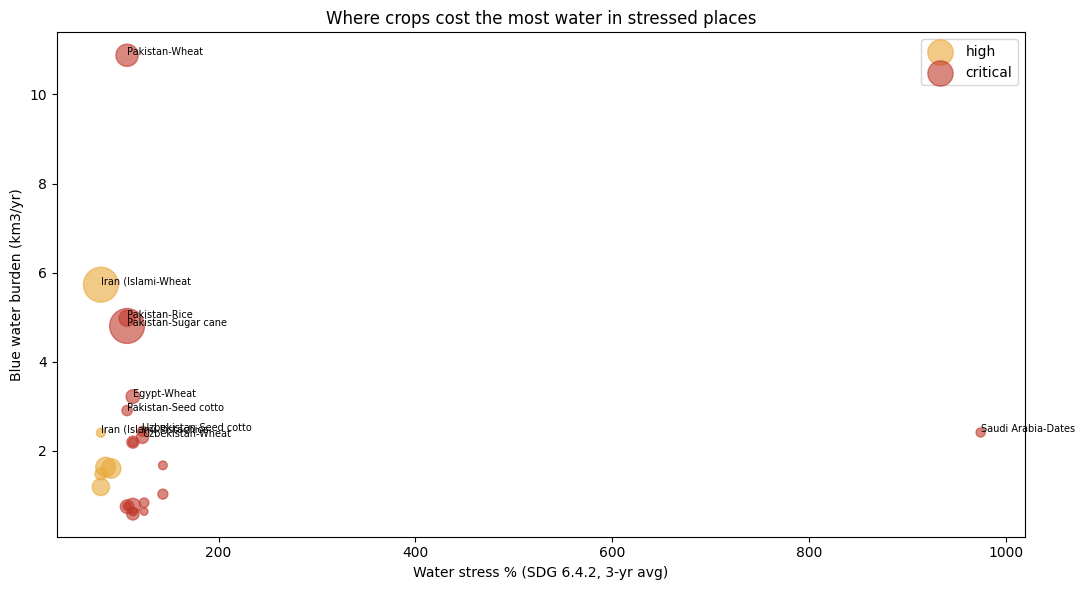

In [8]:
# Section 5b: visual — burden vs stress, bubble = volume
fig, ax = plt.subplots(figsize=(11,6))
for b, color in zip(['high','critical'], ['#e8a838','#c0392b']):
    d = top[top['stress_bin']==b]
    ax.scatter(d['stress_pct'], d['blue_water_km3'], s=d['tons']/d['tons'].max()*600+30, alpha=0.6, color=color, label=b)
for _, r in top.head(10).iterrows():
    ax.annotate(f"{r['Area'][:12]}-{r['Item'][:10]}", (r['stress_pct'], r['blue_water_km3']), fontsize=7)
ax.set_xlabel('Water stress % (SDG 6.4.2, 3-yr avg)'); ax.set_ylabel('Blue water burden (km3/yr)')
ax.set_title('Where crops cost the most water in stressed places'); ax.legend()
plt.tight_layout(); plt.show()

## Section 6: What's impacting them — temperature trend (FAOSTAT ET domain)
'What is impacting them' at country level, kept inside FAOSTAT: annual temperature anomaly since 1961. Rainfall trend (World Bank CCKP) can join later if needed.

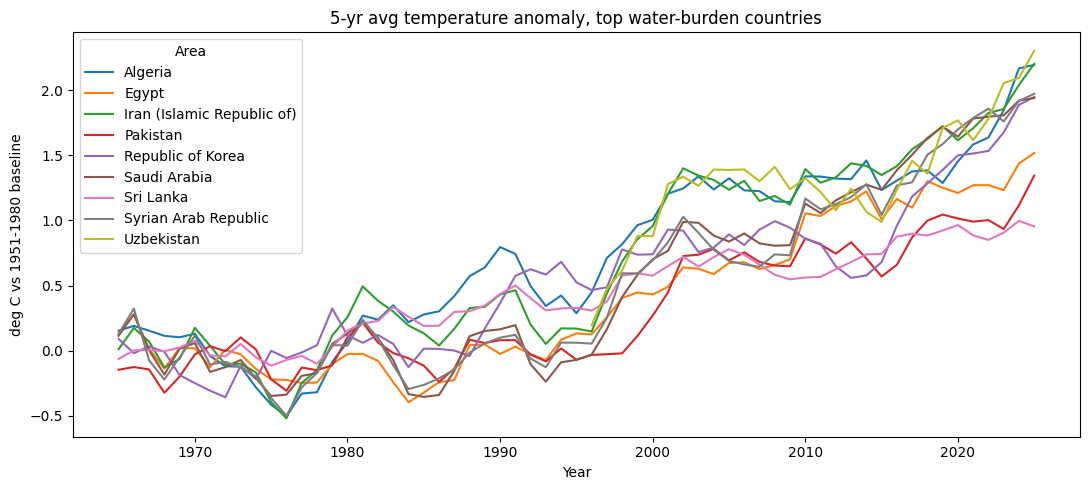

In [9]:
# Section 6: temperature anomaly trend for the top-burden countries
et_all = bulk_csv('https://bulks-faostat.fao.org/production/Environment_Temperature_change_E_All_Data_(Normalized).zip', 'et_bulk.zip')
et = et_all[(et_all['Area Code'].isin(top['Area Code'].unique())) & (et_all['Element'].str.contains('Temperature change', case=False))]
et_yearly = et[et['Months'].str.contains('Meteorological year', case=False, na=False)] if 'Months' in et.columns else et
piv = et_yearly.pivot_table(index='Year', columns='Area', values='Value', aggfunc='mean')
piv.rolling(5).mean().plot(figsize=(11,5), title='5-yr avg temperature anomaly, top water-burden countries')
plt.ylabel('deg C vs 1951-1980 baseline'); plt.tight_layout(); plt.show()

## Section 7: Use vs sell — Food Balances (FBS) for the top pairs (also Shruti's lane)
For each top burden pair:
- How much stays home (food/feed) vs leaves as exports?
- Export share of a water-hungry crop in a stressed country = the virtual-water-export story.
- Self-sufficiency = production / (production + imports - exports).

In [10]:
# Section 7: FBS pull — NOTE: FBS item names differ from QCL (e.g. 'Wheat and products'); match fuzzily and verify
FBS_BULK = 'https://bulks-faostat.fao.org/production/FoodBalanceSheets_E_All_Data_(Normalized).zip'
fbs_all = bulk_csv(FBS_BULK, 'fbs_bulk.zip')
els = ['Production','Import quantity','Export quantity','Food','Feed']
fbs = fbs_all[(fbs_all['Area Code'].isin(top['Area Code'].unique())) & (fbs_all['Element'].isin(els))]
fbs_latest = fbs[fbs['Year'] == fbs['Year'].max()]
wide = fbs_latest.pivot_table(index=['Area','Item'], columns='Element', values='Value', aggfunc='sum').reset_index()
wide['export_share_pct'] = 100 * wide.get('Export quantity',0) / wide.get('Production', np.nan)
wide['self_sufficiency'] = wide.get('Production',0) / (wide.get('Production',0) + wide.get('Import quantity',0) - wide.get('Export quantity',0))
print(wide.sort_values('export_share_pct', ascending=False).head(20).to_string(index=False))

                      Area                       Item  Export quantity  Feed   Food  Import quantity  Production  export_share_pct  self_sufficiency
                   Algeria                Sugar Crops              1.0   NaN    0.0              0.0         0.0               inf         -0.000000
              Saudi Arabia                   Treenuts              7.0   NaN  461.0            478.0         0.0               inf          0.000000
                     Egypt                       Peas              7.0   0.0   22.0             29.0         0.0               inf          0.000000
              Saudi Arabia          Nuts and products              7.0   NaN  461.0            478.0         0.0               inf          0.000000
              Saudi Arabia         Marine Fish, Other              5.0   NaN   40.0             45.0         0.0               inf          0.000000
         Republic of Korea Lemons, Limes and products              1.0   NaN   22.0             24.0      

## Section 8: Producer prices (PP) — Shruti's market-rate layer
Price per ton for the shortlist crops, to pair with trade volumes. Caution from the team notes: this supports 'self-sufficient vs import-dependent, at what price' — the word *subsidy* is not supportable from FAOSTAT alone; keep it off slides unless OECD support data gets pulled (recommend: don't, scope).

In [11]:
# Section 8: producer prices for top-burden pairs
PP_BULK = 'https://bulks-faostat.fao.org/production/Prices_E_All_Data_(Normalized).zip'
pp_all = bulk_csv(PP_BULK, 'pp_bulk.zip')
pp = pp_all[(pp_all['Area Code'].isin(top['Area Code'].unique())) &
            (pp_all['Element'].str.contains('Producer Price', case=False)) &
            (pp_all['Unit'].str.contains('USD', case=False, na=False))]
pp_latest = pp[pp['Year'] >= pp['Year'].max()-2].groupby(['Area','Item'], as_index=False)['Value'].mean().rename(columns={'Value':'usd_per_ton_3yr'})
print(pp_latest.sort_values('usd_per_ton_3yr', ascending=False).head(20).to_string(index=False))

                      Area                                              Item  usd_per_ton_3yr
                  Pakistan                              Pistachios, in shell     16829.433333
              Saudi Arabia       Meat of goat, fresh or chilled (biological)     16343.700000
                 Sri Lanka                      Nutmeg, mace, cardamoms, raw     15262.500000
              Saudi Arabia      Meat of sheep, fresh or chilled (biological)     13512.400000
              Saudi Arabia    Meat of cattle with the bone, fresh or chilled     13214.300000
                  Pakistan Other stimulant, spice and aromatic crops, n.e.c.     11630.100000
              Saudi Arabia                  Meat of camels, fresh or chilled     11167.350000
                 Sri Lanka           Cinnamon and cinnamon-tree flowers, raw      9638.700000
                 Sri Lanka                    Meat of goat, fresh or chilled      8243.150000
                Uzbekistan                              Pist

## Section 9: Verdict + handoff
Run everything, then read this checklist:

| Question | Answered by | Feeds |
|---|---|---|
| Which crops are most expensive for water? | Section 4 (per-ton) + Section 5 (total burden) | Problem statement v2 |
| Where are they grown? | Section 5 table + 5b chart | Kaveesha's Reverse notebook country selection |
| What is impacting them? | Section 6 (temperature), stress trend already in Reverse notebook | Sustain framing |
| Use vs sell / self-sufficiency? | Section 7 | Shruti's visualization |
| At what price? | Section 8 | Shruti's visualization |

**Verify before slides:** (1) replace bootstrap footprints with Report 47 Appendix II per-country values, (2) spot-check one burden number by hand, (3) log every dataset touched (SDGB, QCL, ET, FBS, PP, M&H) in the sources log with today's date.

**Bulk URLs note:** ET/FBS/PP bulk filenames follow FAO's pattern but are unverified; if one 404s, get the exact file via the Bulk Downloads button on that domain's page at fao.org/faostat/en/#data and update the URL.

## Heidi ToDo:
 1. Water stat level check -check aquastat: https://data.apps.fao.org/aquastat/?utm_source=chatgpt.com&lang=en
 2. the binning logic
 3. Explore crops other than Olives (corn (maize) , wheat, barley)